In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

In [27]:
df = pd.read_csv('/content/drive/MyDrive/TSLA.csv')

In [28]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

In [29]:
openValues = df['Open'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(openValues)

In [30]:
window = 12

X, y = [], []
for i in range(len(scaled) - window):
    X.append(scaled[i : i + window])
    y.append(scaled[i + window])
X, y = np.array(X), np.array(y)

In [31]:
TEST_SIZE = 2400
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:]


X_train, y_train = X[:-TEST_SIZE], y[:-TEST_SIZE]
X_test, y_test = X[-TEST_SIZE:], y[-TEST_SIZE:]

In [32]:
model_tsla = models.Sequential()
model_tsla.add(layers.Input(shape=(window, 1)))
model_tsla.add(layers.LSTM(32, return_sequences=False))
model_tsla.add(layers.Dropout(0.2))
model_tsla.add(layers.Dense(1))

model_tsla.compile(optimizer='adam', loss='mse')
model_tsla.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model_tsla.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.0371e-06 - val_loss: 2.7272e-07
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.4409e-07 - val_loss: 1.6356e-07
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.5023e-07 - val_loss: 3.6357e-07
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.6174e-07 - val_loss: 1.8575e-07
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7662e-07 - val_loss: 5.5513e-07
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.0527e-07 - val_loss: 1.9304e-07
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.8094e-07 - val_loss: 2.5315e-07
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.0016e-07 - val_loss: 1.9533e-07
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.6429e-07 - val_loss: 6.8243e-08
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.4201e-07 - val_loss: 6.0511e-08
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.2487e-07 - val

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

첫 번째 테스트 데이터 예측 주가 ($): 5.0435534
첫 번째 테스트 데이터 실제 주가 ($): 5.552


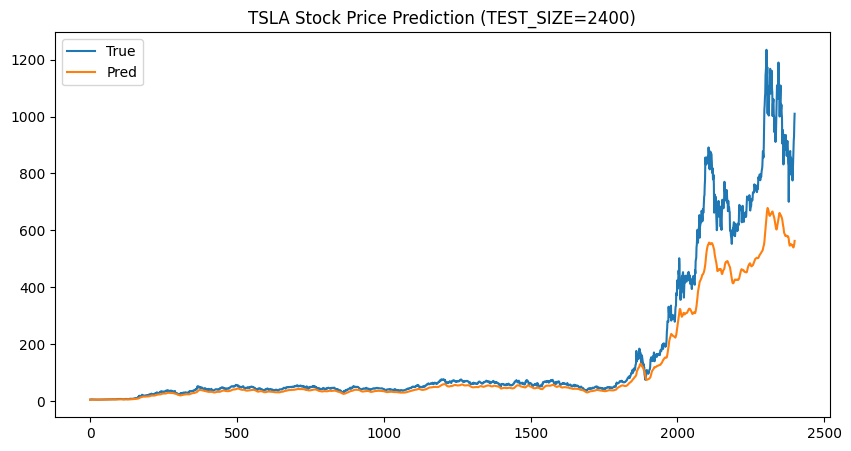

In [34]:
predictions = model_tsla.predict(X_test)


y_test_2d = y_test.reshape(-1, 1)
predictions_2d = predictions.reshape(-1, 1)

original_predictions = scaler.inverse_transform(predictions_2d)
original_y_test = scaler.inverse_transform(y_test_2d)

print("\n" + "="*40)
print("첫 번째 테스트 데이터 예측 주가 ($):", original_predictions[0][0])
print("첫 번째 테스트 데이터 실제 주가 ($):", original_y_test[0][0])
print("="*40)


plt.figure(figsize=(10, 5))
plt.plot(original_y_test, label='True')
plt.plot(original_predictions, label='Pred')
plt.legend()
plt.title("TSLA Stock Price Prediction (TEST_SIZE=2400)")
plt.show()